In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
plt.rcParams['figure.dpi'] = 100


# 1. Hotelling’s $T^2$ Test for a Mean Vector

Given data matrix

$$X = \begin{bmatrix} 2 & 12 \\ 8 & 9 \\ 6 & 9 \\ 8 & 10 \end{bmatrix}$$

##A)



Hypotheses:  
   $H_0:\boldsymbol\mu' = [7,\,11]$  
   $H_1:\boldsymbol\mu' \neq [7,\,11]$

The test statistic is
$$T^2 = n(\bar{\mathbf x}-\boldsymbol\mu_0)'\mathbf S^{-1}(\bar{\mathbf x}-\boldsymbol\mu_0),$$
and under $H_0$, $T^2 \sim \dfrac{(n-1)p}{n-p}F_{p,\,n-p}$.

In [3]:
X = np.array([[2,12],
              [8, 9],
              [6, 9],
              [8,10]], dtype=float)
n, p = X.shape

xbar = X.mean(axis=0)
S = np.cov(X, rowvar=False, ddof=1)
mu0 = np.array([7, 11], dtype=float)

diff = xbar - mu0
Sinv = np.linalg.inv(S)
T2 = n * diff @ Sinv @ diff

print("Sample mean vector, xbar =", xbar)
print("Sample covariance matrix, S =\n", S)
print("S^-1 =\n", Sinv)
print("xbar - mu0 =", diff)
print(f"T^2 = n (xbar-mu0)' S^-1 (xbar-mu0) = {T2:.4f}")


Sample mean vector, xbar = [ 6. 10.]
Sample covariance matrix, S =
 [[ 8.     -3.3333]
 [-3.3333  2.    ]]
S^-1 =
 [[0.4091 0.6818]
 [0.6818 1.6364]]
xbar - mu0 = [-1. -1.]
T^2 = n (xbar-mu0)' S^-1 (xbar-mu0) = 13.6364


Result

$\bar{\mathbf x} = (6,\,10)'$, and with
$\mathbf S=\begin{bmatrix}8 & -10/3\\-10/3 & 2\end{bmatrix}$, the observed statistic is $T^2 = 13.636$.



In [4]:
alpha = 0.05
crit_F  = stats.f.ppf(1-alpha, p, n-p)
const   = (n-1)*p/(n-p)
crit_T2 = const * crit_F

##B)

In [5]:
print(f"Exact null distribution: T^2 ~ [(n-1)p/(n-p)] F(p, n-p) = [{n-1}*{p}/{n-p}] F({p},{n-p}) = {const:.4f} * F({p},{n-p})")
print(f"i.e. T^2 ~ 3 F(2,2)")

Exact null distribution: T^2 ~ [(n-1)p/(n-p)] F(p, n-p) = [3*2/2] F(2,2) = 3.0000 * F(2,2)
i.e. T^2 ~ 3 F(2,2)


Exact null distribution:

 $T^2 \sim \dfrac{(n-1)p}{n-p}F_{p,\,n-p} = 3\,F_{2,2}$.

## C)

In [7]:
print(f"\nCritical F: F_(2,2,0.05) = {crit_F:.4f}")
print(f"Critical T^2 = {const:.4f} * {crit_F:.4f} = {crit_T2:.4f}")
print(f"Observed T^2 = {T2:.4f}")
print(f"Reject H0? {T2 > crit_T2}")


Critical F: F_(2,2,0.05) = 19.0000
Critical T^2 = 3.0000 * 19.0000 = 57.0000
Observed T^2 = 13.6364
Reject H0? False


The critical value is $3\times F_{2,2,0.05} = 3\times 19.00 = 57.00$. Since the observed $T^2=13.636 < 57.00$, we **fail to reject $H_0$**. There is no significant evidence, at the 5% level, that the population mean vector differs from $[7,11]'$ — the observed sample mean is statistically consistent with $\boldsymbol\mu_0$.

#2. Simultaneous Confidence Intervals and Regions for Grizzly Bear Body Measurements

In [8]:
varnames = ["Weight (kg)","Body length (cm)","Neck (cm)","Girth (cm)","Head length (cm)","Head width (cm)"]
xbar2 = np.array([95.52,164.38,55.69,93.39,17.98,31.13])
S2 = np.array([
    [3266.46,1343.97,731.54,1175.50,162.68,238.37],
    [1343.97, 721.91,324.25, 537.35, 80.17,117.73],
    [ 731.54, 324.25,179.28, 281.17, 39.15, 56.80],
    [1175.50, 537.35,281.17, 474.98, 63.73, 94.85],
    [ 162.68,  80.17, 39.15,  63.73,  9.95, 13.88],
    [ 238.37, 117.73, 56.80,  94.85, 13.88, 21.26]])
n2, p2 = 61, 6
alpha = 0.05

print("xbar =", xbar2)
print("diag(S) =", np.diag(S2))

xbar = [ 95.52 164.38  55.69  93.39  17.98  31.13]
diag(S) = [3266.46  721.91  179.28  474.98    9.95   21.26]


##A)


For large $n$, $n(\bar{\mathbf x}-\boldsymbol\mu)'\mathbf S^{-1}(\bar{\mathbf x}-\boldsymbol\mu)$ is approximately $\chi^2_p$, giving simultaneous intervals
$$\bar x_i \pm \sqrt{\chi^2_{p}(\alpha)}\sqrt{s_{ii}/n}.$$

In [10]:
chi2_crit = stats.chi2.ppf(1-alpha, p2)
se2 = np.sqrt(np.diag(S2)/n2)
marg_simul = np.sqrt(chi2_crit)*se2

print(f"chi2_(6, 0.05) = {chi2_crit:.4f}\n")
print(f"{'Variable':18s} {'mean':>9s} {'margin':>9s} {'lower':>10s} {'upper':>10s}")
for i in range(p2):
    lo, hi = xbar2[i]-marg_simul[i], xbar2[i]+marg_simul[i]
    print(f"{varnames[i]:18s} {xbar2[i]:9.3f} {marg_simul[i]:9.3f} {lo:10.3f} {hi:10.3f}")

chi2_(6, 0.05) = 12.5916

Variable                mean    margin      lower      upper
Weight (kg)           95.520    25.967     69.553    121.487
Body length (cm)     164.380    12.207    152.173    176.587
Neck (cm)             55.690     6.083     49.607     61.773
Girth (cm)            93.390     9.902     83.488    103.292
Head length (cm)      17.980     1.433     16.547     19.413
Head width (cm)       31.130     2.095     29.035     33.225


These six intervals are constructed so that, simultaneously, the probability that all six capture their respective population means is approximately 0.95.

##B)

The ellipse for the sub-vector $(\mu_{\text{weight}}, \mu_{\text{girth}})$ is
$$n(\bar{\mathbf x}-\boldsymbol\mu)'\mathbf S^{-1}(\bar{\mathbf x}-\boldsymbol\mu)\le \chi^2_2(0.05),$$
centered at $(\bar x_{\text{weight}},\bar x_{\text{girth}})$, with axes along the eigenvectors of the $2\times2$ sub-covariance matrix, half-lengths $\sqrt{\lambda_i\chi^2_2(\alpha)/n}$.

Center (Weight, Girth): [95.52 93.39]
S_sub =
 [[3266.46 1175.5 ]
 [1175.5   474.98]]
chi2_(2,0.05) = 5.9915
Eigenvalues: [  45.9213 3695.5187]
Eigenvectors (columns):
 [[ 0.3429 -0.9394]
 [-0.9394 -0.3429]]
Half-axis lengths: [ 2.1238 19.0519]


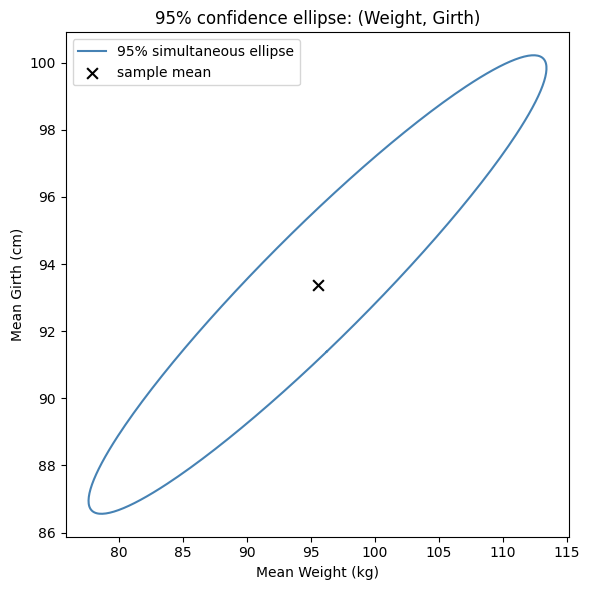

In [12]:
idx = [0, 3]
S_sub = S2[np.ix_(idx, idx)]
xbar_sub = xbar2[idx]
chi2_crit2 = stats.chi2.ppf(1-alpha, 2)
eigval, eigvec = np.linalg.eigh(S_sub)
axis_len = np.sqrt(eigval*chi2_crit2/n2)

print("Center (Weight, Girth):", xbar_sub)
print("S_sub =\n", S_sub)
print(f"chi2_(2,0.05) = {chi2_crit2:.4f}")
print("Eigenvalues:", eigval)
print("Eigenvectors (columns):\n", eigvec)
print("Half-axis lengths:", axis_len)

theta = np.linspace(0, 2*np.pi, 300)
circle = np.column_stack([np.cos(theta), np.sin(theta)])
ellipse_pts = (circle*axis_len) @ eigvec.T + xbar_sub

fig, ax = plt.subplots(figsize=(6,6))
ax.plot(ellipse_pts[:,0], ellipse_pts[:,1], color="steelblue", label="95% simultaneous ellipse")
ax.scatter(*xbar_sub, color="black", marker="x", s=60, label="sample mean")
ax.set_xlabel("Mean Weight (kg)")
ax.set_ylabel("Mean Girth (cm)")
ax.set_title("95% confidence ellipse: (Weight, Girth)")
ax.legend()
plt.tight_layout()
plt.show()


The ellipse is tilted, reflecting the strong positive correlation between weight and girth ($s_{14}=1175.50$): it is long and narrow, running roughly along the direction in which weight and girth increase together, and much narrower in the perpendicular direction. We are fairly confident about the combination of weight and girth even though each mean individually has more uncertainty.

##C)

Bonferroni intervals use $\bar x_i \pm t_{n-1}(\alpha/2m)\sqrt{s_{ii}/n}$ with $m=6$ simultaneous statements.

In [14]:
m = 6
t_crit_bonf = stats.t.ppf(1-alpha/(2*m), n2-1)
marg_bonf = t_crit_bonf*se2

print(f"t_(60, alpha/12) = {t_crit_bonf:.4f}\n")
print(f"{'Variable':18s} {'mean':>9s} {'margin':>9s} {'lower':>10s} {'upper':>10s}")
for i in range(p2):
    lo, hi = xbar2[i]-marg_bonf[i], xbar2[i]+marg_bonf[i]
    print(f"{varnames[i]:18s} {xbar2[i]:9.3f} {marg_bonf[i]:9.3f} {lo:10.3f} {hi:10.3f}")

t_(60, alpha/12) = 2.7286

Variable                mean    margin      lower      upper
Weight (kg)           95.520    19.967     75.553    115.487
Body length (cm)     164.380     9.387    154.993    173.767
Neck (cm)             55.690     4.678     51.012     60.368
Girth (cm)            93.390     7.614     85.776    101.004
Head length (cm)      17.980     1.102     16.878     19.082
Head width (cm)       31.130     1.611     29.519     32.741


Every Bonferroni interval is narrower than its chi-square-based simultaneous counterpart in part (a) (e.g. Weight: $\pm19.97$ vs. $\pm25.97$) — with only $m=6$ statements, Bonferroni's correction is less conservative than the $\chi^2_6$ approach, which is the usual pattern when $p$ is small relative to $n$.


##D)

Bonferroni rectangle (m=6) for Weight & Girth:
  Weight  :   95.520 +/-  19.967  -> (  75.553,  115.487)
  Girth   :   93.390 +/-   7.614  -> (  85.776,  101.004)


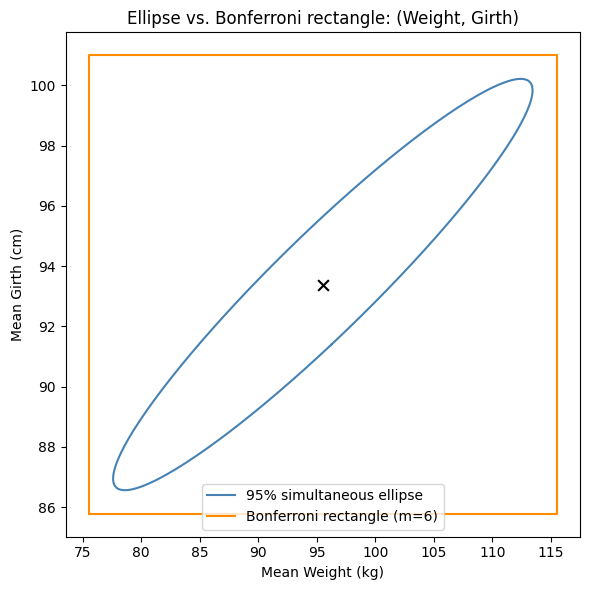

In [15]:
marg_rect = t_crit_bonf*np.sqrt(np.diag(S_sub)/n2)
print("Bonferroni rectangle (m=6) for Weight & Girth:")
for i, name in enumerate(["Weight","Girth"]):
    lo, hi = xbar_sub[i]-marg_rect[i], xbar_sub[i]+marg_rect[i]
    print(f"  {name:8s}: {xbar_sub[i]:8.3f} +/- {marg_rect[i]:7.3f}  -> ({lo:8.3f}, {hi:8.3f})")

fig, ax = plt.subplots(figsize=(6,6))
ax.plot(ellipse_pts[:,0], ellipse_pts[:,1], color="steelblue", label="95% simultaneous ellipse")
rect_x = [xbar_sub[0]-marg_rect[0], xbar_sub[0]+marg_rect[0], xbar_sub[0]+marg_rect[0], xbar_sub[0]-marg_rect[0], xbar_sub[0]-marg_rect[0]]
rect_y = [xbar_sub[1]-marg_rect[1], xbar_sub[1]-marg_rect[1], xbar_sub[1]+marg_rect[1], xbar_sub[1]+marg_rect[1], xbar_sub[1]-marg_rect[1]]
ax.plot(rect_x, rect_y, color="darkorange", label="Bonferroni rectangle (m=6)")
ax.scatter(*xbar_sub, color="black", marker="x", s=60)
ax.set_xlabel("Mean Weight (kg)")
ax.set_ylabel("Mean Girth (cm)")
ax.set_title("Ellipse vs. Bonferroni rectangle: (Weight, Girth)")
ax.legend()
plt.tight_layout()
plt.show()


The Bonferroni rectangle (using $m=6$, to remain consistent with the six simultaneous statements of part (c)) is noticeably tighter along each axis than the bounding box of the ellipse, but — because it is a rectangle — it includes corner regions (extreme weight and extreme girth together) that the ellipse rules out, while the ellipse permits some large joint deviations along its major axis that fall slightly outside the rectangle. Neither region contains the other; they intersect, trading off correlation information (captured by the ellipse) against simplicity of a per-variable statement (the rectangle).

##E)

Using $m=7$ allows for this contrast statement in addition to the six individual-mean statements of part (c).

In [16]:
hw, hl = 5, 4
diff_mean = xbar2[hw] - xbar2[hl]
var_diff  = S2[hw,hw] + S2[hl,hl] - 2*S2[hw,hl]
se_diff   = np.sqrt(var_diff/n2)

m2 = 7
t_crit7 = stats.t.ppf(1-alpha/(2*m2), n2-1)
marg_diff = t_crit7*se_diff

print(f"mean(Head width) - mean(Head length) = {diff_mean:.4f}")
print(f"Var(difference) = s_ww + s_ll - 2 s_wl = {var_diff:.4f},  SE = {se_diff:.4f}")
print(f"t_(60, alpha/14) = {t_crit7:.4f}")
print(f"95% Bonferroni CI (m=7): {diff_mean:.4f} +/- {marg_diff:.4f}  ->  ({diff_mean-marg_diff:.4f}, {diff_mean+marg_diff:.4f})")

mean(Head width) - mean(Head length) = 13.1500
Var(difference) = s_ww + s_ll - 2 s_wl = 3.4500,  SE = 0.2378
t_(60, alpha/14) = 2.7855
95% Bonferroni CI (m=7): 13.1500 +/- 0.6624  ->  (12.4876, 13.8124)


Since $0$ is far outside the interval $(12.49,\,13.81)$, mean head width is significantly larger than mean head length for these bears (by roughly 12.5–13.8 cm), even after accounting for the extra multiple-comparison statement.


## 3. Mineral Analysis of Ancient Peruvian Hairs

$n=9$ hairs; $x_1=$ chromium (ppm), $x_2=$ strontium (ppm).

In [18]:
x1 = np.array([.48, 40.53, 2.19, .55, .74, .66, .93, .37, .22])
x2 = np.array([12.57, 73.68, 11.13, 20.03, 20.29, .78, 4.64, .43, 1.08])
X3 = np.column_stack([x1, x2])
n3, p3 = X3.shape
alpha = 0.10

xbar3 = X3.mean(axis=0)
S3 = np.cov(X3, rowvar=False, ddof=1)
S3inv = np.linalg.inv(S3)

print("n =", n3)
print("xbar =", xbar3)
print("S =\n", S3)


n = 9
xbar = [ 5.1856 16.07  ]
S =
 [[176.0042 287.2412]
 [287.2412 527.8493]]


##A)

Since $n$ is small, we use the **exact** $T^2$ distribution: the 90% confidence region is
$$n(\bar{\mathbf x}-\boldsymbol\mu)'\mathbf S^{-1}(\bar{\mathbf x}-\boldsymbol\mu) \le \frac{(n-1)p}{n-p}F_{p,\,n-p}(0.10).$$


(n-1)p/(n-p) = 2.2857,  F(2,7,0.10) = 3.2574
Critical value c^2 = 7.4456
Eigenvalues: [ 15.0941 688.7594]
Eigenvectors (columns):
 [[-0.8724  0.4887]
 [ 0.4887  0.8724]]
Half-axis lengths: [ 3.5337 23.8705]


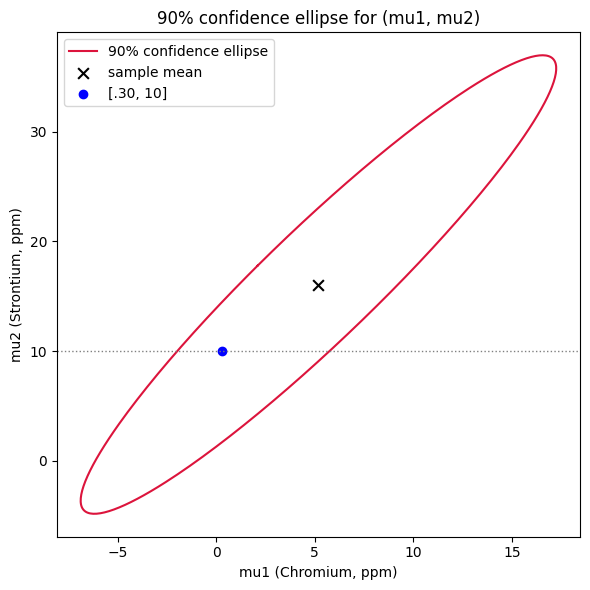

In [19]:
const3 = (n3-1)*p3/(n3-p3)
Fcrit3 = stats.f.ppf(1-alpha, p3, n3-p3)
crit3  = const3*Fcrit3

print(f"(n-1)p/(n-p) = {const3:.4f},  F(2,7,0.10) = {Fcrit3:.4f}")
print(f"Critical value c^2 = {crit3:.4f}")

eigval3, eigvec3 = np.linalg.eigh(S3)
axis_len3 = np.sqrt(eigval3*crit3/n3)
print("Eigenvalues:", eigval3)
print("Eigenvectors (columns):\n", eigvec3)
print("Half-axis lengths:", axis_len3)

theta = np.linspace(0, 2*np.pi, 300)
circle = np.column_stack([np.cos(theta), np.sin(theta)])
ell3 = (circle*axis_len3) @ eigvec3.T + xbar3

fig, ax = plt.subplots(figsize=(6,6))
ax.plot(ell3[:,0], ell3[:,1], color="crimson", label="90% confidence ellipse")
ax.scatter(*xbar3, color="black", marker="x", s=60, label="sample mean")
ax.scatter([.30],[10], color="blue", marker="o", label="[.30, 10]")
ax.axhline(10, color="gray", linestyle=":", linewidth=1)
ax.set_xlabel("mu1 (Chromium, ppm)")
ax.set_ylabel("mu2 (Strontium, ppm)")
ax.set_title("90% confidence ellipse for (mu1, mu2)")
ax.legend()
plt.tight_layout()
plt.show()


## B)

Projecting the ellipse onto each axis gives $\bar x_i \pm \sqrt{c^2}\sqrt{s_{ii}/n}$, with $c^2$ as computed above.

In [20]:
se3 = np.sqrt(np.diag(S3)/n3)
marg3 = np.sqrt(crit3)*se3

for i, name in enumerate(["mu1 (Chromium)", "mu2 (Strontium)"]):
    lo, hi = xbar3[i]-marg3[i], xbar3[i]+marg3[i]
    print(f"{name}: {xbar3[i]:.4f} +/- {marg3[i]:.4f}  ->  ({lo:.4f}, {hi:.4f})")

lo2, hi2 = xbar3[1]-marg3[1], xbar3[1]+marg3[1]
print(f"\nIs mu2 = 10 within the CI for mu2 ({lo2:.4f}, {hi2:.4f})? {lo2 <= 10 <= hi2}")

pt = np.array([.30, 10.0])
diffpt = pt - xbar3
quad = n3*diffpt @ S3inv @ diffpt
print(f"\nTest point mu=[.30, 10]':  n(x-xbar)'S^-1(x-xbar) = {quad:.4f}   vs.  critical value = {crit3:.4f}")
print(f"Is [.30, 10]' inside the 90% ellipse? {quad <= crit3}")


mu1 (Chromium): 5.1856 +/- 12.0667  ->  (-6.8812, 17.2523)
mu2 (Strontium): 16.0700 +/- 20.8970  ->  (-4.8270, 36.9670)

Is mu2 = 10 within the CI for mu2 (-4.8270, 36.9670)? True

Test point mu=[.30, 10]':  n(x-xbar)'S^-1(x-xbar) = 1.7725   vs.  critical value = 7.4456
Is [.30, 10]' inside the 90% ellipse? True


The individual 90% interval for $\mu_2$ (strontium) is roughly $(-4.8,\,37.0)$, so $\mu_2=10$ is comfortably inside it — meaning some point of the form $(\mu_1\text{ arbitrary},\,10)$ does lie in the confidence region (in fact the whole vertical line $\mu_2=10$ intersects the ellipse over a range of $\mu_1$ values).


The specific point $[.30,\,10]'$ also lies *inside* the joint 90% ellipse (quadratic form $1.77 < 7.45$), so it is a plausible value of $\boldsymbol\mu$, even though $\mu_1=.30$ is below the ".100 ppm" diabetes-risk threshold, this single ancient sample cannot statistically rule out a population mean chromium level in that range. Note, however, that checking a single point against the joint ellipse is a stronger (more specific) statement than checking each coordinate separately against the marginal intervals in (b); a point can pass both marginal checks yet still fail the joint check, or vice versa in edge cases, because the ellipse also encodes the correlation between $\mu_1$ and $\mu_2$.

##C)

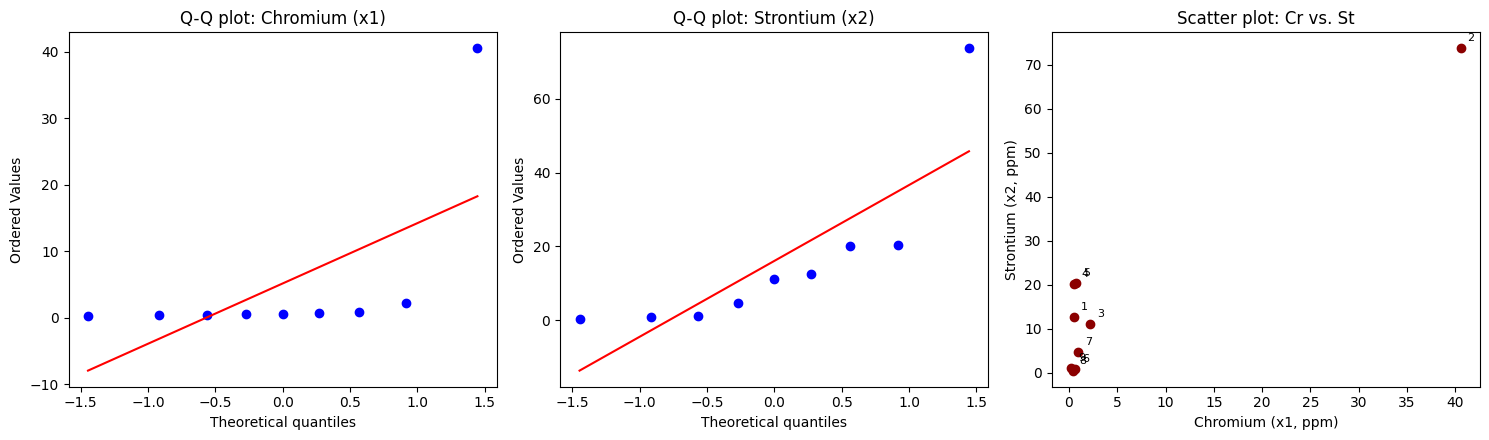

Shapiro-Wilk x1 (Chromium): ShapiroResult(statistic=np.float64(0.423749852687343), pvalue=np.float64(8.08485937171186e-07))
Shapiro-Wilk x2 (Strontium): ShapiroResult(statistic=np.float64(0.6894076514992792), pvalue=np.float64(0.0010673745671484949))


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
stats.probplot(x1, dist="norm", plot=axes[0]); axes[0].set_title("Q-Q plot: Chromium (x1)")
stats.probplot(x2, dist="norm", plot=axes[1]); axes[1].set_title("Q-Q plot: Strontium (x2)")
axes[2].scatter(x1, x2, color="darkred")
for i, (a, b) in enumerate(zip(x1, x2)):
    axes[2].annotate(str(i+1), (a, b), textcoords="offset points", xytext=(5,5), fontsize=8)
axes[2].set_xlabel("Chromium (x1, ppm)"); axes[2].set_ylabel("Strontium (x2, ppm)")
axes[2].set_title("Scatter plot: Cr vs. St")
plt.tight_layout()
plt.show()

print("Shapiro-Wilk x1 (Chromium):", stats.shapiro(x1))
print("Shapiro-Wilk x2 (Strontium):", stats.shapiro(x2))

Squared generalized (Mahalanobis) distances d_i^2: [0.4215 7.0978 0.051  2.3709 2.3416 1.1741 0.4434 1.1567 0.9429]
Chi-square quantiles (df=2): [0.1143 0.3646 0.6508 0.985  1.3863 1.8889 2.5619 3.5835 5.7807]


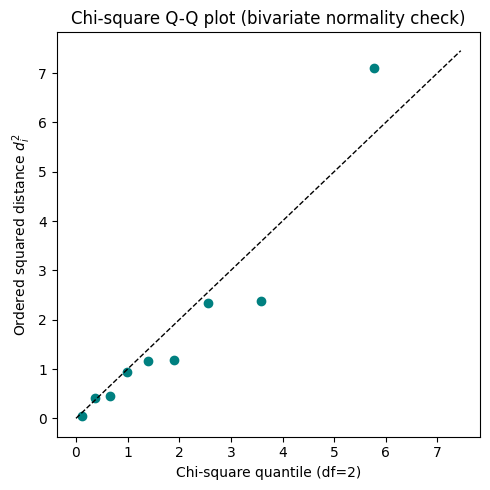

In [22]:
d2 = np.array([(row-xbar3) @ S3inv @ (row-xbar3) for row in X3])
d2_sorted = np.sort(d2)
qs = (np.arange(1, n3+1)-0.5)/n3
chi2_q = stats.chi2.ppf(qs, df=p3)

print("Squared generalized (Mahalanobis) distances d_i^2:", np.round(d2, 4))
print("Chi-square quantiles (df=2):", np.round(chi2_q, 4))

fig, ax = plt.subplots(figsize=(5,5))
ax.scatter(chi2_q, d2_sorted, color="teal")
lims = [0, max(chi2_q.max(), d2_sorted.max())*1.05]
ax.plot(lims, lims, 'k--', linewidth=1)
ax.set_xlabel("Chi-square quantile (df=2)")
ax.set_ylabel("Ordered squared distance $d_i^2$")
ax.set_title("Chi-square Q-Q plot (bivariate normality check)")
plt.tight_layout()
plt.show()

Observation 2 (Cr = 40.53, St = 73.68) is a severe outlier — an order of magnitude beyond every other observation on both variables, clearly visible in the scatter plot and as the point in the extreme upper-right tail of both univariate Q-Q plots. The Shapiro–Wilk tests reject normality decisively for both $x_1$ ($p\approx 8\times10^{-7}$) and $x_2$ ($p\approx.001$), driven largely by this single point. The chi-square Q-Q plot also shows the same observation as a clear departure from the reference line. Bivariate normality is not a good description of these data, mainly because of this one contaminating hair (possibly a measurement error, a different individual/culture, or a genuinely different exposure history).

The $T^2$-based ellipse and simultaneous intervals are derived under an assumption of (at least approximate) multivariate normality. With such a small sample ($n=9$) and one dominant outlier, $\bar{\mathbf x}$ and $\mathbf S$ are both heavily influenced by that single observation, so the ellipse and intervals in (a)–(b) are not reliable — they may be badly distorted (inflated variance, shifted mean) relative to what the "typical" ancient Peruvian population actually looked like.

##D)

In [23]:
mask = np.ones(9, dtype=bool)
mask[1] = False
x1o, x2o = x1[mask], x2[mask]
X3o = np.column_stack([x1o, x2o])
n3o, p3o = X3o.shape

xbar3o = X3o.mean(axis=0)
S3o = np.cov(X3o, rowvar=False, ddof=1)
S3o_inv = np.linalg.inv(S3o)

print("n =", n3o)
print("xbar =", xbar3o)
print("S =\n", S3o)

const3o = (n3o-1)*p3o/(n3o-p3o)
Fcrit3o = stats.f.ppf(1-alpha, p3o, n3o-p3o)
crit3o  = const3o*Fcrit3o
print(f"\n(n-1)p/(n-p) = {const3o:.4f}, F(2,6,0.10) = {Fcrit3o:.4f}, critical value = {crit3o:.4f}")

eigval3o, eigvec3o = np.linalg.eigh(S3o)
axis_len3o = np.sqrt(eigval3o*crit3o/n3o)
print("Half-axis lengths:", axis_len3o)

se3o = np.sqrt(np.diag(S3o)/n3o)
marg3o = np.sqrt(crit3o)*se3o
for i, name in enumerate(["mu1 (Chromium)", "mu2 (Strontium)"]):
    lo, hi = xbar3o[i]-marg3o[i], xbar3o[i]+marg3o[i]
    print(f"  {name}: {xbar3o[i]:.4f} +/- {marg3o[i]:.4f}  ->  ({lo:.4f}, {hi:.4f})")

pt = np.array([.30, 10.0])
diffpt = pt - xbar3o
quad_o = n3o*diffpt @ S3o_inv @ diffpt
print(f"\nTest point [.30, 10]': quadratic form = {quad_o:.4f} vs. critical value {crit3o:.4f} -> inside ellipse: {quad_o<=crit3o}")

print("\nShapiro-Wilk x1 (outlier removed):", stats.shapiro(x1o))
print("Shapiro-Wilk x2 (outlier removed):", stats.shapiro(x2o))

n = 8
xbar = [0.7675 8.8688]
S =
 [[ 0.3786  1.0303]
 [ 1.0303 69.8598]]

(n-1)p/(n-p) = 2.3333, F(2,6,0.10) = 3.4633, critical value = 8.0810
Half-axis lengths: [0.6058 8.4014]
  mu1 (Chromium): 0.7675 +/- 0.6184  ->  (0.1491, 1.3859)
  mu2 (Strontium): 8.8688 +/- 8.4004  ->  (0.4683, 17.2692)

Test point [.30, 10]': quadratic form = 5.3079 vs. critical value 8.0810 -> inside ellipse: True

Shapiro-Wilk x1 (outlier removed): ShapiroResult(statistic=np.float64(0.7618218873944693), pvalue=np.float64(0.011026429550558482))
Shapiro-Wilk x2 (outlier removed): ShapiroResult(statistic=np.float64(0.8580281941498066), pvalue=np.float64(0.11475372085189267))


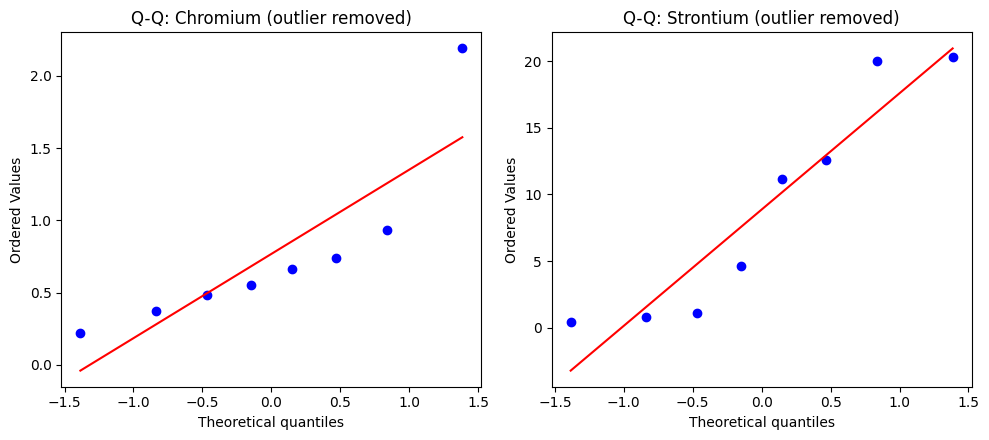

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
stats.probplot(x1o, dist="norm", plot=axes[0]); axes[0].set_title("Q-Q: Chromium (outlier removed)")
stats.probplot(x2o, dist="norm", plot=axes[1]); axes[1].set_title("Q-Q: Strontium (outlier removed)")
plt.tight_layout()
plt.show()


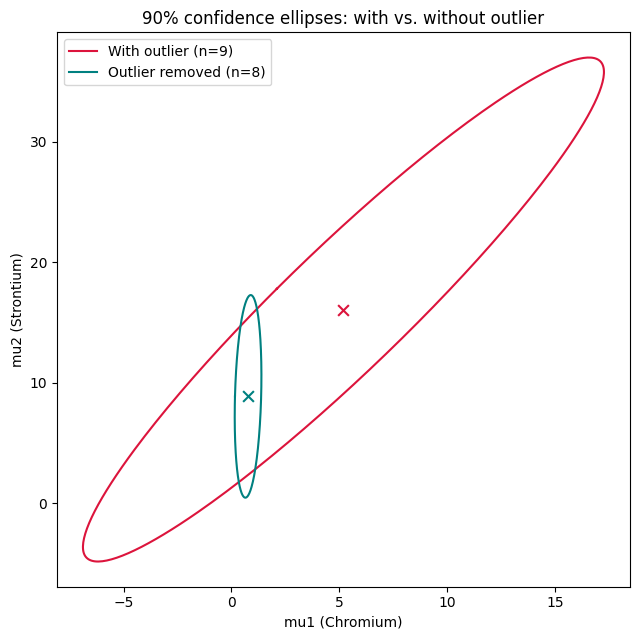

In [25]:
def ellipse_points(center, S, crit_val, n, npts=300):
    eigval, eigvec = np.linalg.eigh(S)
    theta = np.linspace(0, 2*np.pi, npts)
    circle = np.column_stack([np.cos(theta), np.sin(theta)])
    axes_len = np.sqrt(eigval*crit_val/n)
    return (circle*axes_len) @ eigvec.T + center

ell_full = ellipse_points(xbar3, S3, crit3, n3)
ell_out  = ellipse_points(xbar3o, S3o, crit3o, n3o)

fig, ax = plt.subplots(figsize=(6.5,6.5))
ax.plot(ell_full[:,0], ell_full[:,1], label="With outlier (n=9)", color="crimson")
ax.plot(ell_out[:,0], ell_out[:,1], label="Outlier removed (n=8)", color="teal")
ax.scatter(*xbar3, color="crimson", marker="x", s=60)
ax.scatter(*xbar3o, color="teal", marker="x", s=60)
ax.set_xlabel("mu1 (Chromium)"); ax.set_ylabel("mu2 (Strontium)")
ax.set_title("90% confidence ellipses: with vs. without outlier")
ax.legend()
plt.tight_layout()
plt.show()


Removing the outlier changes the picture substantially:
- The sample mean drops sharply (Chromium: $5.19\to0.77$; Strontium: $16.07\to8.87$), and the covariance matrix shrinks a great deal — the confidence ellipse is now far smaller and no longer tilted the same way.
- $[.30,\,10]'$ is *still* inside the (much smaller) 90% ellipse, so the earlier conclusion that it is a plausible mean value is unchanged.
- Both Shapiro–Wilk p-values move toward (Strontium) or stay below (Chromium, though less extreme) the 0.05 threshold; the Q-Q plots look much closer to a straight line without the outlier, though Chromium still shows some right-skew (all values here are small and positive, consistent with a variable that is not perfectly Gaussian but far less problematic than before).
- **Overall**, the outlier was driving most of the departure from bivariate normality and most of the earlier ellipse's size and orientation. With it removed, the T²-based inference is on much firmer ground, but the fact that removing a single observation out of nine changes the results this much is itself a strong signal that $n=9$ is too small to draw confident conclusions about this population — more data (and a look into whether that hair was reasonably included in the sample) would be needed for a resilient conclusion.


#4. Lumber Strength Measurements

$n=30$ pieces of lumber; $x_1=$ stiffness, $x_2=$ bending strength

In [26]:
lumber = [
    (1232,4175),(1115,6652),(2205,7612),(1897,10914),(1932,10850),
    (1612,7627),(1598,6954),(1804,8365),(1752,9469),(2067,6410),
    (2365,10327),(1646,7320),(1579,8196),(1880,9709),(1773,10370),
    (1712,7749),(1932,6818),(1820,9307),(1900,6457),(2426,10102),
    (1558,7414),(1470,7556),(1858,7833),(1587,8309),(2208,9559),
    (1487,6255),(2206,10723),(2332,5430),(2540,12090),(2322,10072)]
X4 = np.array(lumber, dtype=float)
n4, p4 = X4.shape
x1_4, x2_4 = X4[:,0], X4[:,1]
alpha = 0.05

xbar4 = X4.mean(axis=0)
S4 = np.cov(X4, rowvar=False, ddof=1)
S4inv = np.linalg.inv(S4)

print("n =", n4)
print("xbar =", xbar4)
print("S =\n", S4)

n = 30
xbar = [1860.5    8354.1333]
S =
 [[ 124054.6724  361620.4483]
 [ 361620.4483 3486333.154 ]]


##A)

(n-1)p/(n-p) = 2.0714, F(2,28,0.05) = 3.3404, critical value = 6.9194
Eigenvalues: [  85601.3756 3524786.4509]
Half-axis lengths: [140.5119 901.6522]


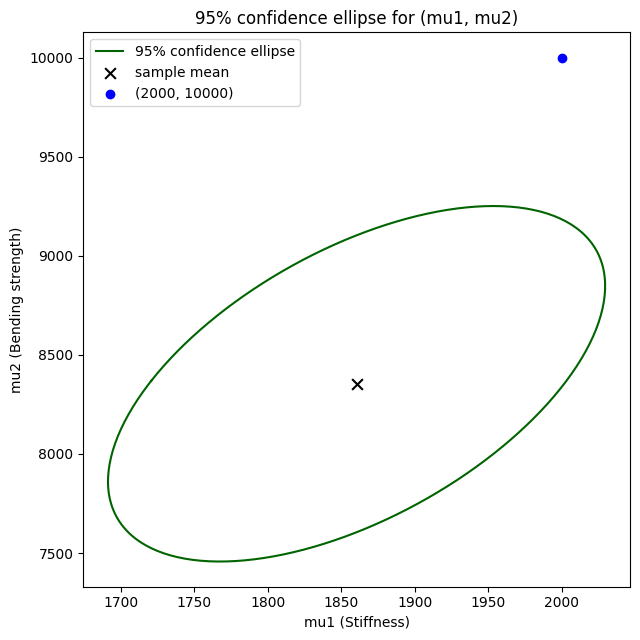

In [27]:
const4 = (n4-1)*p4/(n4-p4)
Fcrit4 = stats.f.ppf(1-alpha, p4, n4-p4)
crit4  = const4*Fcrit4

print(f"(n-1)p/(n-p) = {const4:.4f}, F(2,28,0.05) = {Fcrit4:.4f}, critical value = {crit4:.4f}")

eigval4, eigvec4 = np.linalg.eigh(S4)
axis_len4 = np.sqrt(eigval4*crit4/n4)
print("Eigenvalues:", eigval4)
print("Half-axis lengths:", axis_len4)

theta = np.linspace(0, 2*np.pi, 300)
circle = np.column_stack([np.cos(theta), np.sin(theta)])
ell4 = (circle*axis_len4) @ eigvec4.T + xbar4

fig, ax = plt.subplots(figsize=(6.5,6.5))
ax.plot(ell4[:,0], ell4[:,1], color="darkgreen", label="95% confidence ellipse")
ax.scatter(*xbar4, color="black", marker="x", s=60, label="sample mean")
ax.scatter(2000, 10000, color="blue", marker="o", label="(2000, 10000)")
ax.set_xlabel("mu1 (Stiffness)"); ax.set_ylabel("mu2 (Bending strength)")
ax.set_title("95% confidence ellipse for (mu1, mu2)")
ax.legend()
plt.tight_layout()
plt.show()


##B)

In [28]:
mu0_4 = np.array([2000.0, 10000.0])
diff4 = xbar4 - mu0_4
T2_4 = n4*diff4 @ S4inv @ diff4

print("xbar - mu0 =", diff4)
print(f"T^2 = {T2_4:.4f}   vs.   critical value = {crit4:.4f}")
print(f"Is (2000, 10000) inside the 95% ellipse (i.e. plausible)? {T2_4 <= crit4}")

xbar - mu0 = [ -139.5    -1645.8667]
T^2 = 23.6478   vs.   critical value = 6.9194
Is (2000, 10000) inside the 95% ellipse (i.e. plausible)? False


$T^2 = 23.65$ far exceeds the critical value of $6.92$ (equivalently, the point $(2000,10000)$ lies well outside the ellipse plotted above), so we **reject** the hypothesis that $(\mu_1,\mu_2) = (2000,10000)$. The sample mean, $(1860.5,\ 8354.1)$, is significantly different from these "typical" values. In this sample, both average stiffness and, especially, average bending strength are noticeably below the assumed typical figures.

##C)

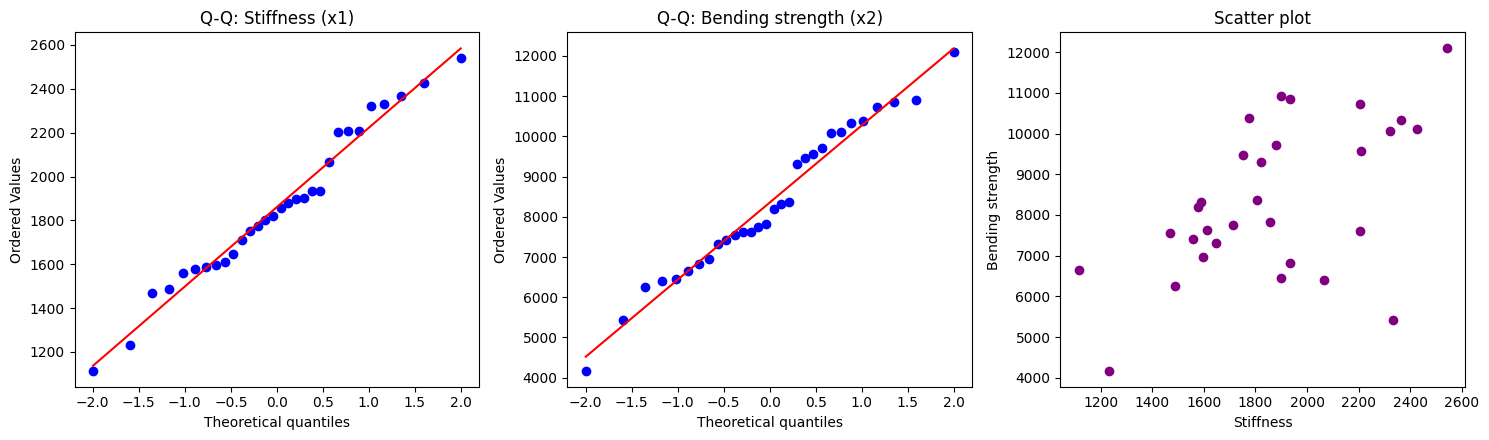

Shapiro-Wilk x1 (Stiffness): ShapiroResult(statistic=np.float64(0.9749014412733477), pvalue=np.float64(0.6798247364747123))
Shapiro-Wilk x2 (Bending strength): ShapiroResult(statistic=np.float64(0.9755163807412185), pvalue=np.float64(0.6979455286860622))


In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
stats.probplot(x1_4, dist="norm", plot=axes[0]); axes[0].set_title("Q-Q: Stiffness (x1)")
stats.probplot(x2_4, dist="norm", plot=axes[1]); axes[1].set_title("Q-Q: Bending strength (x2)")
axes[2].scatter(x1_4, x2_4, color="purple")
axes[2].set_xlabel("Stiffness"); axes[2].set_ylabel("Bending strength")
axes[2].set_title("Scatter plot")
plt.tight_layout()
plt.show()

print("Shapiro-Wilk x1 (Stiffness):", stats.shapiro(x1_4))
print("Shapiro-Wilk x2 (Bending strength):", stats.shapiro(x2_4))


Proportion of d_i^2 <= chi2_(2, 0.5) (expect ~0.5 under bivariate normality): 0.5


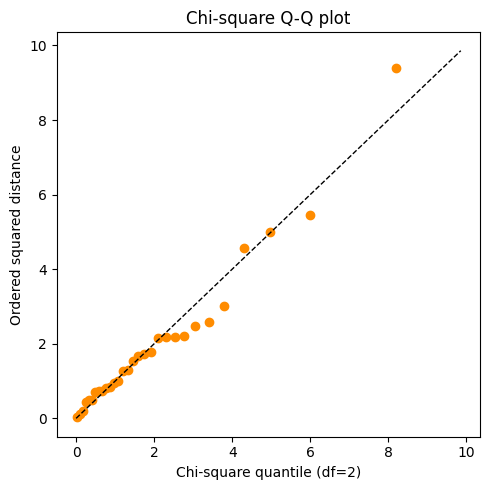

In [30]:
d2_4 = np.array([(row-xbar4) @ S4inv @ (row-xbar4) for row in X4])
d2_4_sorted = np.sort(d2_4)
qs4 = (np.arange(1, n4+1)-0.5)/n4
chi2_q4 = stats.chi2.ppf(qs4, df=p4)
prop_within = np.mean(d2_4 <= stats.chi2.ppf(0.5, df=p4))

print("Proportion of d_i^2 <= chi2_(2, 0.5) (expect ~0.5 under bivariate normality):", prop_within)

fig, ax = plt.subplots(figsize=(5,5))
ax.scatter(chi2_q4, d2_4_sorted, color="darkorange")
lims = [0, max(chi2_q4.max(), d2_4_sorted.max())*1.05]
ax.plot(lims, lims, 'k--', linewidth=1)
ax.set_xlabel("Chi-square quantile (df=2)")
ax.set_ylabel("Ordered squared distance")
ax.set_title("Chi-square Q-Q plot")
plt.tight_layout()
plt.show()


Both univariate Q-Q plots track the reference line closely with no strong outliers, the scatter plot shows a roughly elliptical, positively-correlated cloud of points with no obvious clusters or extreme points, and the Shapiro–Wilk tests for both variables give large p-values ($\approx0.68$ and $\approx0.70$), giving no evidence against univariate normality. Exactly half ($15/30$) of the squared generalized distances fall below the $\chi^2_2$ median, matching the theoretical expectation, and the chi-square Q-Q plot follows the 45° reference line reasonably well throughout its range.
Overall, bivariate normality is a very reasonable model for this lumber data. It is considerably more plausible than for the small, outlier-contaminated Peruvian hair data in Problem 3 — which lends good support to the validity of the ellipse and hypothesis test in items a and b.